# Homework 4 — Solutions: Quantum Phase Estimation & Shor's Algorithm
**Notebook:** Full solutions with QFT, inverse QFT, and phase estimation circuits

## Overview

Complete solutions to Homework 4 covering the **Quantum Fourier Transform (QFT)**
and **Quantum Phase Estimation (QPE)** — the foundation of Shor's algorithm.

### Shor's algorithm context
Shor's algorithm factors integers in polynomial time $O((\log N)^3)$ vs
the best classical algorithm $O(e^{(\log N)^{1/3}})$ — **superpolynomial speedup**.

The quantum part of Shor's algorithm is QPE applied to the modular exponentiation
unitary $U|y\rangle = |ay \bmod N\rangle$, whose eigenvalues encode the period $r$
needed to factor $N$.

### QFT review
$$\text{QFT}|j\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi ijk/N}|k\rangle$$

Implemented with $O(n^2)$ gates: Hadamard + controlled phase rotations + SWAPs.

### Homework 4

<b> Problem 1: Quantum Fourier Transform </b>
Design the quantum circuit which implements QFT for $n=2$ and $n=3$ Qbits and
test it using qiskit.  


 <br />
<br />
  
<b> Solution </b>

By definition the QFT is the following unitary operation

 $QFT|x\rangle = \frac{1}{2^{n/2}}\sum_{y=0}^{2^n-1}e^{2\pi i \frac{xy}{2^n}} |y\rangle$

Note that here $xy$ is a usual multiplication. Let's unwrap this expression to understand how it can be implemeted in the real circuit. First let's represent $y$  in binary, i.e. $y=y_1 y_2 \dots y_n$ where $y_j$ are either 0 or 1, so

 $y = \sum\limits_{k=1}^{n} 2^{n-k} y_k$

Thus

 $\frac{1}{2^{n/2}}\sum_{y=0}^{2^n-1}e^{2\pi i \frac{xy}{2^n}} |y\rangle = 
 \frac{1}{2^{n/2}}\sum_{y=0}^{2^n-1}e^{2\pi ix \left[ \sum_{k=1}^{n} y_k / 2^k \right]} 
 |y_1 y_2 \dots y_n\rangle  = 
 \frac{1}{2^{n/2}}\sum_{y=0}^{2^n-1}\prod_{k=1}^{n}e^{2\pi ix y_k / 2^k } |y_1 y_2 \dots y_n\rangle = \\ =
 \frac{1}{2^{n/2}}\prod_{k=1}^{n}\left( e^{2\pi ix 0 / 2^k } |0\rangle_k + e^{2\pi ix 1 / 2^k } |1\rangle_k \right)= 
 \frac{1}{2^{n/2}}\prod_{k=1}^{n}\left( |0\rangle_k + e^{2\pi ix / 2^k } |1\rangle_k \right)= \\ =
 \frac{1}{2^{n/2}} \left( |0\rangle_1 + e^{2\pi ix / 2 } |1\rangle_1  \right) \otimes 
 \left( |0\rangle_2 + e^{2\pi ix / 2^2 }  |1\rangle_2  \right) \otimes 
 \dots \otimes
 \left( |0\rangle_{n-1} + e^{2\pi ix / 2^{n-1} } |1\rangle_{n-1}  \right) 
 \otimes \left( |0\rangle_n + e^{2\pi ix / 2^n } |1\rangle_n  \right)$

We can see that we can construct such a state using single Q-bit gates

 $H|x_k\rangle = \frac{1}{\sqrt{2}}\left( |0\rangle + (-1)^{x_k}|1\rangle \right) \equiv \frac{1}{\sqrt{2}}
 \left( |0\rangle + e^{2\pi i x_k / 2}|1\rangle \right)$

This is already almost what we want

But we need a phase before the $|1\rangle_k$ state to be equal to $2\pi i x/2^k$. So we have to perform several additional rotations around the $z$-axis

Let's examine the following state

 $\prod_{j=k+1}^{n} C_j ROT_k H |x\rangle_k$

where $C_j ROT_k$ is the controled rotation of the Q-bit $k$ around the $z$ axis on the angle $2\pi/2^k$ with the control Q-bit $j$. We can explicitly rewrite $C_j ROT_k$ in the following form

 $C_j ROT_k |1\rangle_k = e^{2\pi i x_j/2^k} |1\rangle_k$

Which basically means that we add phase $2\pi x_j/2^k$ if the control Q-bit $x_j=1$. 

Noting again that $x/2^n = \sum_{j=1}^{n} x_j / 2^j$

 $\prod_{j=k+1}^{n} C_j ROT_k H |x\rangle_k = \frac{1}{\sqrt{2}} \left( |0\rangle_k + e^{2\pi i \sum_{j=k}^{n}  x_j / 2^j} |1\rangle_k\right) = \frac{1}{\sqrt{2}} \left( |0\rangle_k + e^{2\pi i x / 2^{(n-k)}} |1\rangle_k\right)$

So we get what we wanted, but the Q-bit numbers should be reversed after all the gates, i.e $k \rightarrow n-k$

Qiskit implemetation of QFT

In [86]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile


In [87]:
def qft(qc, n):
    """Apply QFT to the first n qubits of qc (in-place).

    Implements the standard QFT circuit:
      For each qubit (from most-significant to least-significant):
        1. Apply Hadamard to create an equal superposition.
        2. Apply controlled-phase rotations from lower-index qubits,
           adding phase e^{2*pi*i / 2^k} conditioned on each control qubit.
        3. A barrier separates each qubit's block for readability.
      After all rotations, swap qubit pairs to reverse the bit order,
      matching the standard QFT output convention.
    """
    for i in range(n):
        qb = n - i - 1  # process qubits from high index down to 0

        # Hadamard puts this qubit into (|0> + e^{i*phi}|1>) / sqrt(2)
        qc.h(qb)

        # Controlled-phase gates from lower qubits add the fractional binary
        # phase contributions: angle = pi / 2^(j+1) for j = 0, 1, ...
        for j in range(n - i - 1):
            qc.cp(np.pi / np.power(2, j + 1), qb - j - 1, qb)

        qc.barrier()  # visual separator between qubit blocks

    # Bit-reversal permutation: swap qubits to match QFT output ordering
    for qb in range(n // 2):
        qc.swap(qb, n - qb - 1)

Visualise cirquits

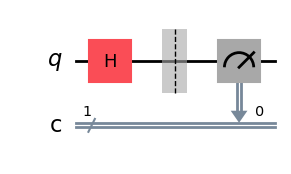

In [88]:
n=1
qc1 = QuantumCircuit(n, n)
#qc1.initialize(init, range(n))
qft(qc1, n)
qc1.measure(range(n), range(n));
qc1.draw(output='mpl',justify='none')

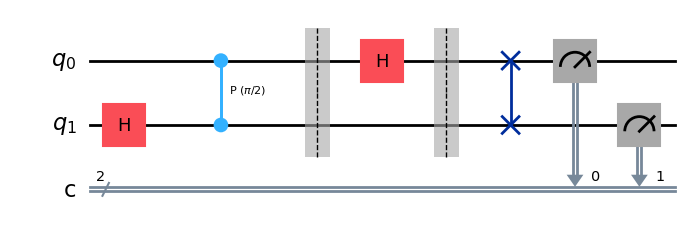

In [89]:
n=2
qc1 = QuantumCircuit(n, n)
#qc1.initialize(init, range(n))
qft(qc1, n)
qc1.measure(range(n), range(n));
qc1.draw(output='mpl',justify='none')

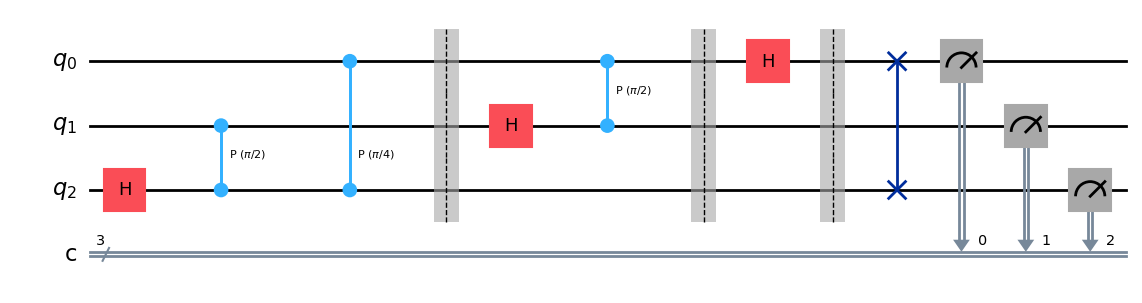

In [90]:
n=3
qc1 = QuantumCircuit(n, n)
#qc1.initialize(init, range(n))
qft(qc1, n)
qc1.measure(range(n), range(n));
qc1.draw(output='mpl',justify='none')

In [91]:
n = 3
l = np.power(2, n)  # total number of basis states = 2^n

# Generate a random normalized complex state vector of dimension 2^n
# This will be used as the test input to both the quantum and classical QFT
real = np.random.rand(l) - 0.5
imag = np.random.rand(l) - 0.5
init = real + 1j * imag
init /= np.linalg.norm(init)   # normalize to unit length (valid quantum state)
init

array([ 0.06471623+0.10086949j,  0.30549288+0.11101618j,
        0.41851781-0.17422781j,  0.04242933-0.2174907j ,
        0.12619463+0.06460066j,  0.45786998+0.12110745j,
        0.34798145+0.11390879j, -0.46059877-0.18639726j])

n = 3
l = np.power(2, n)
# Generating random initial state
init = (np.random.rand(2 * l).astype(complex) - 0.5) * 2
init /= np.linalg.norm(init)
init = init.reshape(l, 2)
init[:,1] *= 1j
init = init[:,0] + init[:,1]
init

In [92]:
# Manually compute the QFT (classical DFT) for verification.
# QFT|j> = (1/sqrt(N)) * sum_k e^{2*pi*i*j*k/N} |k>
# This classical computation gives the expected output amplitudes to compare
# against the Qiskit circuit simulation.
est = np.arange(l).astype(complex)
for i, y in enumerate(est):
    amp = np.zeros_like(init).astype(complex)
    for j, x in enumerate(init):
        # Apply the DFT kernel: multiply amplitude x by e^{2*pi*i*i*j/l}
        amp[j] = np.exp(2 * np.pi * 1j * i * j / l) * x
    # Sum all contributions and normalize by 1/sqrt(l)
    est[i] = 1 / np.sqrt(l) * np.sum(amp)
est

array([ 0.4605399 -0.02355132j, -0.07341935+0.13067463j,
       -0.42836528+0.49756328j,  0.05053991+0.07029681j,
        0.21645129+0.09790439j,  0.2336909 -0.05515195j,
        0.02136282-0.33790623j, -0.29775504-0.09452761j])

In [93]:
qc = QuantumCircuit(n, n)
qc.initialize(init, range(n))
qft(qc, n)
qc.measure(range(n), range(n))

In [94]:
# Execute on the local AerSimulator
backend_sim = AerSimulator()
shots = 1024
res = backend_sim.run(transpile(qc, backend_sim), shots=shots).result()
res = np.array([[int(key, 2), val / shots] for key, val in res.get_counts().items()])

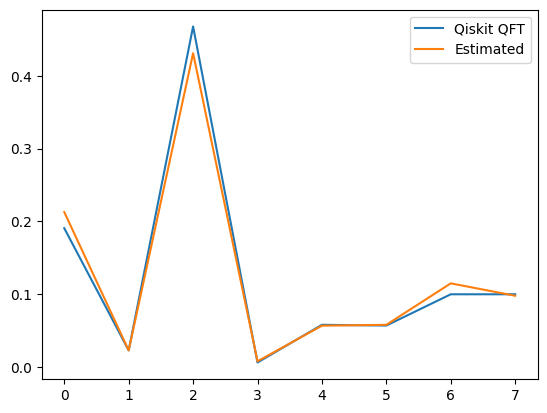

In [95]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()
ax.plot(res[np.argsort(res[:,0]),1], label='Qiskit QFT')
ax.plot(np.arange(l),np.abs(est)**2, label='Estimated')
ax.legend()

The plots coincide, thus our circuit indeed perofrm QFT

<b> Problem 2: Shor' algorith in qiskit </b>

 Design the quantum circuit which can find periods for the modular exponent $a^x (mod N)$ with some small number $a$ and $N$, e.g. $a=3$, $N=10$ or $a=2$, $N=9$. Test the algorithm using qiskit.
 
 <br />

  
<b> Solution </b>
We will use similar approach as in Qiskit tutorial. The key component is the realization of modular exponent $a^x (mod N)$ using qunatum operators. 


In [96]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from math import gcd
from numpy.random import randint
import pandas as pd
from fractions import Fraction

backend = AerSimulator()

Let's investigate the period $a^r mod N =1$ analytically

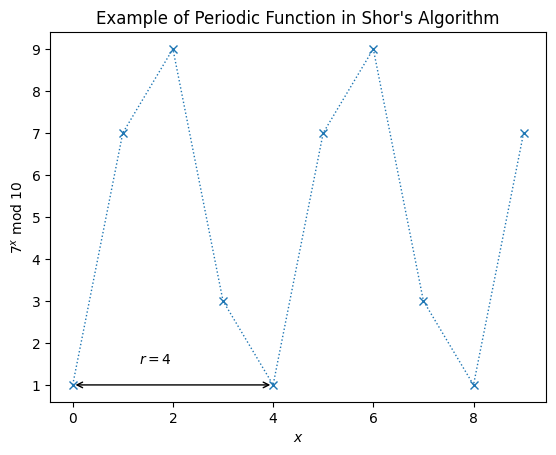

In [97]:
N = 10
a = 7

# Calculate the plotting data
xvals = np.arange(10)
yvals = [np.mod(a**x, N) for x in xvals]

# Use matplotlib to display it nicely
fig, ax = plt.subplots()
ax.plot(xvals, yvals, linewidth=1, linestyle='dotted', marker='x')
ax.set(xlabel='$x$', ylabel='$%i^x$ mod $%i$' % (a, N),
       title="Example of Periodic Function in Shor's Algorithm")
try: # plot r on the graph
    r = yvals[1:].index(1) +1 
    plt.annotate(text='', xy=(0,1), xytext=(r,1), arrowprops=dict(arrowstyle='<->'))
    plt.annotate(text='$r=%i$' % r, xy=(r/3,1.5))
except:
    print('Could not find period, check a < N and have no common factors.')

In [98]:
def qft_dagger(n):
    """n-qubit inverse QFT on the first n qubits.

    Constructs QFT† by reversing the QFT circuit structure:
      1. Bit-reversal: swap qubit i with qubit (n-1-i) to reverse register order.
      2. For each qubit j, apply controlled-phase rotations with negated angles
         (-pi/2^(j-m)) before the Hadamard — this is the complex conjugate of the
         forward QFT rotations, implementing R_k†.
    The result maps the frequency-domain register state back to the phase value
    encoded as a computational basis integer, which is then read out by measurement.
    """
    qc = QuantumCircuit(n)

    # Step 1: bit-reversal permutation to correct output qubit ordering
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)

    # Step 2: reversed Hadamard + conjugated phase gate pattern
    for j in range(n):
        for m in range(j):
            # Controlled-R†_{j-m}: negative angle conjugates the forward QFT phase
            qc.cp(-np.pi / float(2 ** (j - m)), m, j)
        # Hadamard completes the inverse butterfly for qubit j
        qc.h(j)

    qc.name = "QFT†"
    return qc

In [99]:
def U4():
    """Controlled-U^4 gate: implements multiplication by 81 mod 10 = 1 mod 10.

    Since 3^4 = 81 ≡ 1 (mod 10), U^4 is the identity on the computational subspace.
    An empty circuit is used — applying U^4 does nothing, so it can be omitted.
    This gate is included for completeness to show the QPE structure.
    """
    U = QuantumCircuit(4)
    # No gates needed: 3^4 mod 10 = 1, so U^4 = identity
    U = U.to_gate()
    U.name = "U4"
    c_U = U.control()  # controlled identity — no-op in the circuit
    return c_U

In [100]:
def U2():
    """Controlled-U^2 gate: implements multiplication by 9 mod 10.

    3^2 = 9 mod 10. Acting on |1> = |0001>:
      U^2|0001> = |1001>  (decimal 9 in 4-bit binary)
    The only change from |0001> to |1001> is flipping qubit 3 (X gate).
    """
    U = QuantumCircuit(4)
    U.x(3)          # flip qubit 3: maps |0001> -> |1001> = 9 mod 10
    U = U.to_gate()
    U.name = "U2"
    c_U = U.control()  # controlled gate for QPE counting register
    return c_U

In [101]:
def U1():
    """Controlled-U^1 gate: implements multiplication by 3 mod 10.

    U_3 acts on the two relevant inputs:
      |0001> -> |0011>  (1 -> 3): binary 0001 -> 0011
      |1001> -> |0111>  (9 -> 7): binary 1001 -> 0111
    The combined action is: X on qubit 1, then SWAP(3,2).
    Gate order matters — these do not commute.
    """
    U = QuantumCircuit(4)
    U.x(1)          # flip qubit 1: contributes to both 1->3 and 9->7 mappings
    U.swap(3, 2)    # swap upper bits: completes the modular-3 permutation
    U = U.to_gate()
    U.name = "U1"
    c_U = U.control()  # controlled gate for QPE counting register
    return c_U

In [102]:
# --- QPE circuit construction ---
# n_count = 3 counting qubits give 3 bits of phase precision (2^3 = 8 possible values).
# 4 additional qubits hold the target register acted on by the U gates.
n_count = 3
qc = QuantumCircuit(n_count + 4, n_count)

# Step 1: Hadamard on all counting qubits — creates equal superposition |+>^n
# This is the QPE initialization; each counting qubit will accumulate phase.
for q in range(n_count):
    qc.h(q)

# Step 2: Initialize the target register in state |1> = |0001>
# QPE requires an eigenstate of U; |1> is in the eigenspace of U_3 mod 10.
qc.x(3 + n_count)

# Step 3: Apply controlled-U^(2^k) for each counting qubit k.
# Qubit q=0 controls U^1 (= U^(2^0)), but U^4 = identity so q=0 contributes nothing.
# Qubit q=1 controls U^2 (= U^(2^1) = 3^2 mod 10 = 9 mod 10).
# Qubit q=2 controls U^1 (= U^(2^2) mod period — since period=4, 2^2 mod 4 = 0 -> identity,
#   but here q=2 uses U1 implementing U^1 directly as the reduced operator).
for q in range(n_count):
    if q == 1:
        # Controlled-U^2: multiply by 9 mod 10 if counting qubit 1 is |1>
        qc.append(U2(), [q] + [i + n_count for i in range(4)])
    if q == 2:
        # Controlled-U^1: multiply by 3 mod 10 if counting qubit 2 is |1>
        qc.append(U1(), [q] + [i + n_count for i in range(4)])

# Step 4: Inverse QFT on the counting register
# Converts accumulated phases into a computational basis state encoding phi
qc.append(qft_dagger(n_count), range(n_count))

# Step 5: Measure the counting register to read off the estimated phase
qc.measure(range(n_count), range(n_count))
qc.draw('text')

┌───┐              ┌───────┐┌─┐      
q_0: ┤ H ├──────────────┤0      ├┤M├──────
     ├───┤              │       │└╥┘┌─┐   
q_1: ┤ H ├───■──────────┤1 QFT† ├─╫─┤M├───
     ├───┤   │          │       │ ║ └╥┘┌─┐
q_2: ┤ H ├───┼──────■───┤2      ├─╫──╫─┤M├
     └───┘┌──┴──┐┌──┴──┐└───────┘ ║  ║ └╥┘
q_3: ─────┤0    ├┤0    ├──────────╫──╫──╫─
          │     ││     │          ║  ║  ║ 
q_4: ─────┤1    ├┤1    ├──────────╫──╫──╫─
          │  U2 ││  U1 │          ║  ║  ║ 
q_5: ─────┤2    ├┤2    ├──────────╫──╫──╫─
     ┌───┐│     ││     │          ║  ║  ║ 
q_6: ┤ X ├┤3    ├┤3    ├──────────╫──╫──╫─
     └───┘└─────┘└─────┘          ║  ║  ║ 
c: 3/═════════════════════════════╩══╩══╩═
                                  0  1  2

In [103]:
# Create QuantumCircuit with n_count=3 counting qubits
# plus 4 qubits for U to act on
n_count=3
qc = QuantumCircuit(n_count + 4, n_count)

# Initialise counting qubits
# in state |+>
for q in range(n_count):
    qc.h(q)
    
# And ancilla register in state |1>
qc.x(3+n_count)

# Do controlled-U operations
for q in range(n_count):
#    if q==1: 
#        qc.append(U4(), 
#                 [q] + [i+n_count for i in range(4)])
    if q==1: 
        qc.append(U2(), 
                 [q] + [i+n_count for i in range(4)])
    if q==2: 
        qc.append(U1(), 
                 [q] + [i+n_count for i in range(4)])

# Do inverse-QFT
qc.append(qft_dagger(n_count), range(n_count))

# Measure circuit
qc.measure(range(n_count), range(n_count))
qc.draw('text')

┌───┐              ┌───────┐┌─┐      
q_0: ┤ H ├──────────────┤0      ├┤M├──────
     ├───┤              │       │└╥┘┌─┐   
q_1: ┤ H ├───■──────────┤1 QFT† ├─╫─┤M├───
     ├───┤   │          │       │ ║ └╥┘┌─┐
q_2: ┤ H ├───┼──────■───┤2      ├─╫──╫─┤M├
     └───┘┌──┴──┐┌──┴──┐└───────┘ ║  ║ └╥┘
q_3: ─────┤0    ├┤0    ├──────────╫──╫──╫─
          │     ││     │          ║  ║  ║ 
q_4: ─────┤1    ├┤1    ├──────────╫──╫──╫─
          │  U2 ││  U1 │          ║  ║  ║ 
q_5: ─────┤2    ├┤2    ├──────────╫──╫──╫─
     ┌───┐│     ││     │          ║  ║  ║ 
q_6: ┤ X ├┤3    ├┤3    ├──────────╫──╫──╫─
     └───┘└─────┘└─────┘          ║  ║  ║ 
c: 3/═════════════════════════════╩══╩══╩═
                                  0  1  2

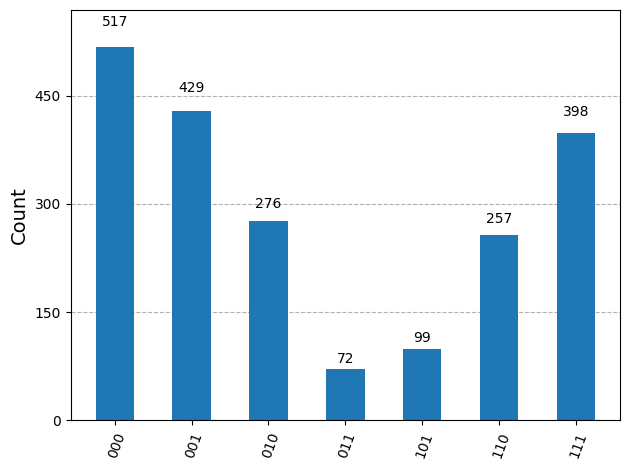

In [104]:
backend = AerSimulator()
results = backend.run(transpile(qc, backend), shots=2048).result()
counts = results.get_counts()
plot_histogram(counts)

In [105]:
rows, measured_phases = [], []
for output in counts:
    # Convert the binary measurement bitstring to a decimal integer
    decimal = int(output, 2)
    # Normalize by 2^n_count: QPE encodes phi as k/2^n where k is the measured integer
    phase = decimal / (2**n_count)
    measured_phases.append(phase)
    # Store both the raw register output and the decoded phase value
    rows.append(["%s(bin) = %i(dec)" % (output, decimal),
                 "%i/%i = %.2f" % (decimal, 2**n_count, phase)])
# Print the rows in a table
headers = ["Register Output", "Phase"]
df = pd.DataFrame(rows, columns=headers)
print(df)

     Register Output       Phase
0  001(bin) = 1(dec)  1/8 = 0.12
1  111(bin) = 7(dec)  7/8 = 0.88
2  010(bin) = 2(dec)  2/8 = 0.25
3  000(bin) = 0(dec)  0/8 = 0.00
4  011(bin) = 3(dec)  3/8 = 0.38
5  110(bin) = 6(dec)  6/8 = 0.75
6  101(bin) = 5(dec)  5/8 = 0.62


In [106]:
rows = []
for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(15)
    rows.append([phase, "%i/%i" % (frac.numerator, frac.denominator), frac.denominator])
# Print as a tableyyhn bhjkl.
headers=["Phase", "Fraction", "Guess for r"]
df = pd.DataFrame(rows, columns=headers)
print(df)

   Phase Fraction  Guess for r
0  0.125      1/8            8
1  0.875      7/8            8
2  0.250      1/4            4
3  0.000      0/1            1
4  0.375      3/8            8
5  0.750      3/4            4
6  0.625      5/8            8


Comparing with the above plot one can see that the procedure works. 